# E6：五数据集 refinement 箱线图统一重绘

本 notebook **不依赖旧 kernel、模型或 GPU**。它会从 `/home/yzm/ipy/e6_iter_results` 递归发现已经保存的正式 `.npz`，把 `indices` 和 `mse_curves` 加载到当前内存，然后统一重画：

- MNIST
- Fashion-MNIST
- CIFAR-10
- CIFAR-100
- Tiny-ImageNet

每个数据集各导出一张 PDF 和 PNG；MNIST 额外导出兼容论文现有文件名的 `refineBox.pdf`。绘图尺寸、字体、配色、均值菱形、零线、网格和标注均按给定 `refineBox.pdf` 统一。

直接 **Run All** 即可。自动发现会排除 `smoke/` 和 `*.partial.npz`，并要求分片完整；Tiny-ImageNet 在存在多个完整结果组时优先选择 `full/` 下的三分片结果。


In [1]:
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps

RESULT_ROOT = Path("/home/yzm/ipy/e6_iter_results")
OUTPUT_DIR = RESULT_ROOT / "refinement_boxplots_all_datasets"

EXPECTED_T = 100
EXPECTED_B = 300
EXPECTED_TEST_SIZE = 10_000
STRICT_TEST_SIZE = True

DATASETS = [
    "mnist",
    "fashion-mnist",
    "cifar10",
    "cifar100",
    "tiny-image-net",
]
DATASET_LABELS = {
    "mnist": "MNIST",
    "fashion-mnist": "Fashion-MNIST",
    "cifar10": "CIFAR-10",
    "cifar100": "CIFAR-100",
    "tiny-image-net": "Tiny-ImageNet",
}
METHODS = ("vae", "sdvae")

if not RESULT_ROOT.is_dir():
    raise FileNotFoundError(f"结果根目录不存在：{RESULT_ROOT}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("result root:", RESULT_ROOT)
print("figure output:", OUTPUT_DIR)


result root: /home/yzm/ipy/e6_iter_results
figure output: /home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets


In [2]:
RESULT_NAME_RE = re.compile(
    r"^(?P<dataset>mnist|fashion-mnist|cifar10|cifar100|tiny-image-net)_"
    r"(?P<method>vae|sdvae)_T(?P<T>\d+)_B(?P<B>\d+)_"
    r"shard(?P<shard>\d+)of(?P<total>\d+)\.npz$"
)


def _is_excluded(path):
    # 排除 smoke 目录和断点文件，避免把测试/未完成结果当正式结果。
    return (
        path.name.lower().endswith(".partial.npz")
        or any("smoke" in part.lower() for part in path.parts)
    )


def discover_complete_groups(root):
    grouped = defaultdict(dict)
    ignored = []

    for path in sorted(root.rglob("*.npz")):
        if _is_excluded(path):
            continue
        match = RESULT_NAME_RE.match(path.name)
        if match is None:
            ignored.append(path)
            continue

        meta = match.groupdict()
        key = (
            path.parent.resolve(),
            meta["dataset"],
            meta["method"],
            int(meta["T"]),
            int(meta["B"]),
            int(meta["total"]),
        )
        shard_id = int(meta["shard"])
        if shard_id in grouped[key]:
            raise RuntimeError(f"同一分片组出现重复 shard {shard_id}：{path}")
        grouped[key][shard_id] = path

    complete = []
    incomplete = []
    for (parent, dataset, method, steps, batch, total), shard_map in grouped.items():
        expected_ids = set(range(total))
        actual_ids = set(shard_map)
        item = {
            "parent": parent,
            "dataset": dataset,
            "method": method,
            "T": steps,
            "B": batch,
            "total_shards": total,
            "files": [shard_map[i] for i in sorted(shard_map)],
        }
        if actual_ids == expected_ids:
            complete.append(item)
        else:
            item["missing_shards"] = sorted(expected_ids - actual_ids)
            incomplete.append(item)

    return complete, incomplete, ignored


def count_group_rows(group):
    total_rows = 0
    for path in group["files"]:
        with np.load(path, allow_pickle=False) as data:
            if "indices" not in data.files:
                raise KeyError(f"{path} 缺少 indices")
            total_rows += len(data["indices"])
    return total_rows


complete_groups, incomplete_groups, ignored_npz = discover_complete_groups(RESULT_ROOT)
print(f"发现完整结果组 {len(complete_groups)} 个；不完整结果组 {len(incomplete_groups)} 个")
if incomplete_groups:
    for group in incomplete_groups:
        print(
            "忽略不完整组：",
            group["dataset"], group["method"], group["parent"],
            "missing", group["missing_shards"],
        )


发现完整结果组 10 个；不完整结果组 0 个


In [3]:
def select_group(dataset, method):
    candidates = [
        group for group in complete_groups
        if group["dataset"] == dataset
        and group["method"] == method
        and group["T"] == EXPECTED_T
        and group["B"] == EXPECTED_B
    ]
    if not candidates:
        raise FileNotFoundError(
            f"找不到 {dataset}/{method} 的完整 T={EXPECTED_T}, B={EXPECTED_B} 结果组"
        )

    for group in candidates:
        group["N"] = count_group_rows(group)
        parent_parts = {part.lower() for part in group["parent"].parts}
        group["tiny_full_priority"] = int(
            dataset == "tiny-image-net" and "full" in parent_parts
        )
        group["newest_mtime"] = max(path.stat().st_mtime for path in group["files"])

    # Tiny 优先 full/；其余情况优先样本最多、分片数更多、mtime 更新的完整组。
    candidates.sort(
        key=lambda group: (
            group["tiny_full_priority"],
            group["N"],
            group["total_shards"],
            group["newest_mtime"],
        ),
        reverse=True,
    )
    selected = candidates[0]
    if len(candidates) > 1:
        print(f"{dataset}/{method} 有 {len(candidates)} 个完整候选，自动选择：{selected['parent']}")
    return selected


def load_group_into_memory(group):
    if len(group["files"]) != group["total_shards"]:
        raise RuntimeError(
            f"分片数量错误：期望 {group['total_shards']}，实际 {len(group['files'])}"
        )

    index_parts = []
    curve_parts = []
    for path in group["files"]:
        with np.load(path, allow_pickle=False) as data:
            required = {"indices", "mse_curves"}
            missing = required - set(data.files)
            if missing:
                raise KeyError(f"{path} 缺少字段：{sorted(missing)}")

            indices = np.asarray(data["indices"], dtype=np.int64).copy()
            curves = np.asarray(data["mse_curves"], dtype=np.float64).copy()
            if curves.ndim != 2 or curves.shape[0] != len(indices):
                raise ValueError(
                    f"{path} 形状不一致：indices={indices.shape}, mse_curves={curves.shape}"
                )
            if curves.shape[1] != EXPECTED_T + 2:
                raise ValueError(
                    f"{path} 应有 {EXPECTED_T + 2} 个轨迹点，实际 {curves.shape[1]}"
                )
            if not np.isfinite(curves).all():
                raise ValueError(f"{path} 的 mse_curves 含 NaN/Inf")
            if "T" in data.files and int(np.asarray(data["T"]).item()) != group["T"]:
                raise ValueError(f"{path} 内部 T 与文件名不一致")
            if "B" in data.files and int(np.asarray(data["B"]).item()) != group["B"]:
                raise ValueError(f"{path} 内部 B 与文件名不一致")

            index_parts.append(indices)
            curve_parts.append(curves)

    indices = np.concatenate(index_parts)
    curves = np.concatenate(curve_parts, axis=0)
    order = np.argsort(indices, kind="stable")
    indices = indices[order]
    curves = curves[order]

    duplicate_mask = np.diff(indices) == 0
    if duplicate_mask.any():
        duplicated = np.unique(indices[:-1][duplicate_mask])[:10]
        raise ValueError(f"分片合并后 indices 重复，示例：{duplicated.tolist()}")
    if STRICT_TEST_SIZE and len(indices) != EXPECTED_TEST_SIZE:
        raise ValueError(
            f"{group['dataset']}/{group['method']} 合并后 N={len(indices)}，"
            f"期望完整测试集 N={EXPECTED_TEST_SIZE}"
        )

    delta = curves[:, -1] - curves[:, 0]  # final - init；负值表示 refinement 改善
    return {"indices": indices, "mse_curves": curves, "delta": delta}


In [4]:
# 所有正式结果在本 cell 结束后都保存在 results_in_memory 中，不依赖旧 kernel。
results_in_memory = {}
selection_rows = []

for dataset in DATASETS:
    results_in_memory[dataset] = {}
    for method in METHODS:
        group = select_group(dataset, method)
        loaded = load_group_into_memory(group)
        results_in_memory[dataset][method] = loaded
        selection_rows.append({
            "dataset": DATASET_LABELS[dataset],
            "method": method.upper(),
            "N": len(loaded["indices"]),
            "shards": group["total_shards"],
            "directory": str(group["parent"]),
        })

    vae_indices = results_in_memory[dataset]["vae"]["indices"]
    sdvae_indices = results_in_memory[dataset]["sdvae"]["indices"]
    if not np.array_equal(vae_indices, sdvae_indices):
        raise ValueError(f"{dataset} 的 VAE/SDVAE indices 不完全一致，不能做严格配对比较")

selection_df = pd.DataFrame(selection_rows)
display(selection_df)
print("五个数据集的 VAE/SDVAE 结果已全部加载并通过完整性检查。")


,dataset,method,N,shards,directory
0,MNIST,VAE,10000,1,/home/yzm/ipy/e6_iter_results
1,MNIST,SDVAE,10000,1,/home/yzm/ipy/e6_iter_results
2,Fashion-MNIST,VAE,10000,1,/home/yzm/ipy/e6_iter_results
3,Fashion-MNIST,SDVAE,10000,1,/home/yzm/ipy/e6_iter_results
4,CIFAR-10,VAE,10000,1,/home/yzm/ipy/e6_iter_results
5,CIFAR-10,SDVAE,10000,1,/home/yzm/ipy/e6_iter_results
6,CIFAR-100,VAE,10000,1,/home/yzm/ipy/e6_iter_results
7,CIFAR-100,SDVAE,10000,1,/home/yzm/ipy/e6_iter_results
8,Tiny-ImageNet,VAE,10000,3,/home/yzm/ipy/e6_iter_results/tiny-image-net/full
9,Tiny-ImageNet,SDVAE,10000,3,/home/yzm/ipy/e6_iter_results/tiny-image-net/full


五个数据集的 VAE/SDVAE 结果已全部加载并通过完整性检查。


In [5]:
def summarize_delta(values):
    values = np.asarray(values, dtype=np.float64)
    n = len(values)
    mean = values.mean()
    std = values.std(ddof=1)
    sem = sps.sem(values)
    ci_low, ci_high = sps.t.interval(0.95, n - 1, loc=mean, scale=sem)
    p_improve = sps.ttest_1samp(values, 0.0, alternative="less").pvalue
    return {
        "N": n,
        "mean_delta_mse": mean,
        "std_delta_mse": std,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "improved_ratio": (values < 0).mean(),
        "one_sided_p_improve": p_improve,
    }


summary_rows = []
for dataset in DATASETS:
    for method in METHODS:
        row = {
            "dataset": DATASET_LABELS[dataset],
            "method": method.upper(),
        }
        row.update(summarize_delta(results_in_memory[dataset][method]["delta"]))
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(
    summary_df.style.format({
        "mean_delta_mse": "{:+.4f}",
        "std_delta_mse": "{:.4f}",
        "ci95_low": "{:+.4f}",
        "ci95_high": "{:+.4f}",
        "improved_ratio": "{:.2%}",
        "one_sided_p_improve": "{:.3g}",
    })
)


,dataset,method,N,mean_delta_mse,std_delta_mse,ci95_low,ci95_high,improved_ratio,one_sided_p_improve
0,MNIST,VAE,10000,-2.1537,3.2935,-2.2182,-2.0891,90.66%,0
1,MNIST,SDVAE,10000,+1.2377,5.0106,+1.1395,+1.3360,28.36%,1
2,Fashion-MNIST,VAE,10000,-0.4449,1.2084,-0.4686,-0.4212,67.60%,1.03e-278
3,Fashion-MNIST,SDVAE,10000,+2.1336,2.7744,+2.0793,+2.1880,9.36%,1
4,CIFAR-10,VAE,10000,+0.4779,2.3579,+0.4317,+0.5241,28.06%,1
5,CIFAR-10,SDVAE,10000,-0.7052,2.6553,-0.7572,-0.6531,62.29%,1.61e-150
6,CIFAR-100,VAE,10000,-0.2237,2.6798,-0.2762,-0.1712,42.95%,3.94e-17
7,CIFAR-100,SDVAE,10000,-0.6340,3.8437,-0.7094,-0.5587,57.94%,1.25e-60
8,Tiny-ImageNet,VAE,10000,-8.6580,12.6439,-8.9059,-8.4102,95.35%,0
9,Tiny-ImageNet,SDVAE,10000,-13.4327,17.1365,-13.7686,-13.0968,99.14%,0


In [6]:
BOX_COLORS = ["#4C72B0", "#C05A2A"]
ZERO_COLOR = "#FF6B6B"
EDGE_COLOR = "#BDBDBD"

# 给定 refineBox.pdf 的 MediaBox：350.965 × 249.945 pt。
# PDF 不再使用 bbox_inches="tight"，确保五张图的页面物理尺寸严格一致。
REFERENCE_FIGSIZE = (350.965 / 72.0, 249.945 / 72.0)


def plot_refinement_boxplot(dataset, vae_delta, sdvae_delta, output_dir):
    values = [np.asarray(vae_delta), np.asarray(sdvae_delta)]
    if len(values[0]) != len(values[1]):
        raise ValueError(f"{dataset}: VAE/SDVAE 样本数不一致")

    with plt.rc_context({
        "font.family": "DejaVu Sans",
        "font.size": 10.0,
        "axes.labelsize": 10.0,
        "xtick.labelsize": 10.0,
        "ytick.labelsize": 10.0,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }):
        fig, ax = plt.subplots(figsize=REFERENCE_FIGSIZE, dpi=150)
        bp = ax.boxplot(
            values,
            showfliers=False,
            widths=0.46,
            patch_artist=True,
            boxprops=dict(linewidth=1.25, edgecolor=EDGE_COLOR),
            whiskerprops=dict(linewidth=1.15, color=EDGE_COLOR),
            capprops=dict(linewidth=1.15, color=EDGE_COLOR),
            medianprops=dict(linewidth=1.6, color="white"),
        )
        for patch, color in zip(bp["boxes"], BOX_COLORS):
            patch.set_facecolor(color)
            patch.set_alpha(0.78)

        ax.axhline(0, color=ZERO_COLOR, lw=1.25, ls="--")
        ax.set_xticks([1, 2], ["VAE", "SDVAE"])
        ax.set_ylabel(r"$\Delta$MSE after 100 BAM steps (final $-$ init)")
        ax.yaxis.grid(True, alpha=0.25, ls=":")
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_xlim(0.55, 2.75)

        for x, method_values in zip([1, 2], values):
            mean_value = method_values.mean()
            ax.plot(
                x, mean_value, marker="D", ms=6, color="black",
                markeredgecolor="white", markeredgewidth=1.0, zorder=4,
            )
            ax.annotate(
                f"mean {mean_value:+.2f}",
                xy=(x + 0.25, mean_value),
                va="center",
                fontsize=10,
            )

        # 参考图无标题；数据集由文件名区分。
        fig.tight_layout(pad=0.6)

        pdf_path = output_dir / f"refineBox_{dataset}.pdf"
        png_path = output_dir / f"refineBox_{dataset}.png"
        fig.savefig(pdf_path)
        fig.savefig(png_path, dpi=220)
        if dataset == "mnist":
            fig.savefig(output_dir / "refineBox.pdf")

        plt.show()
        return pdf_path, png_path


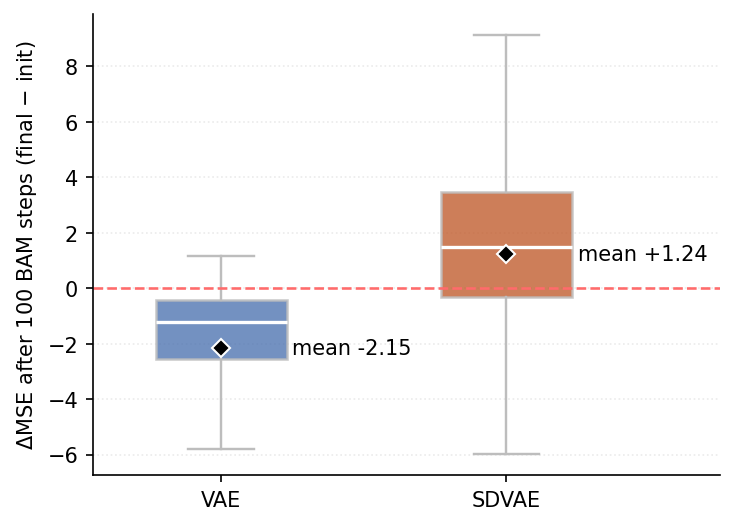

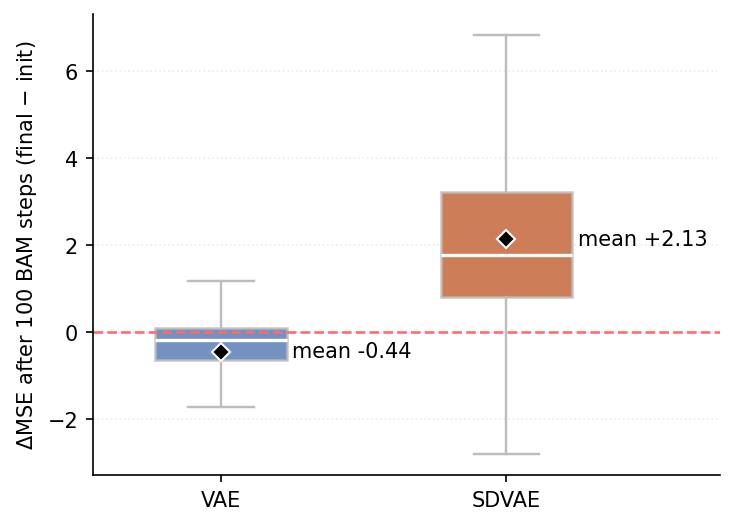

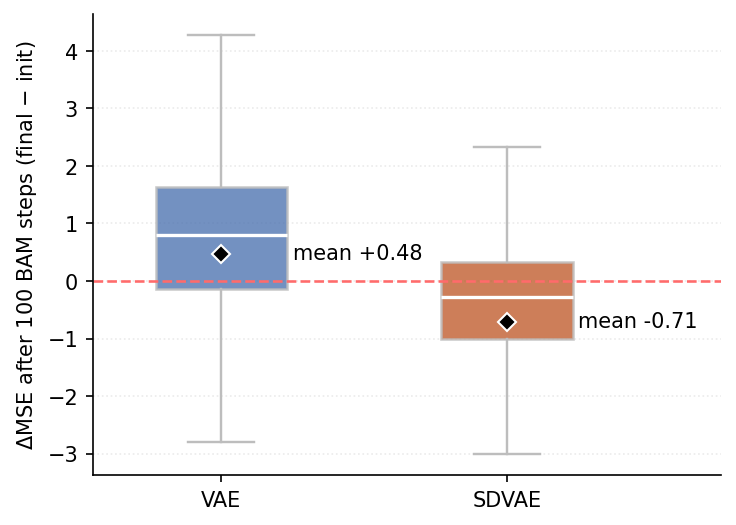

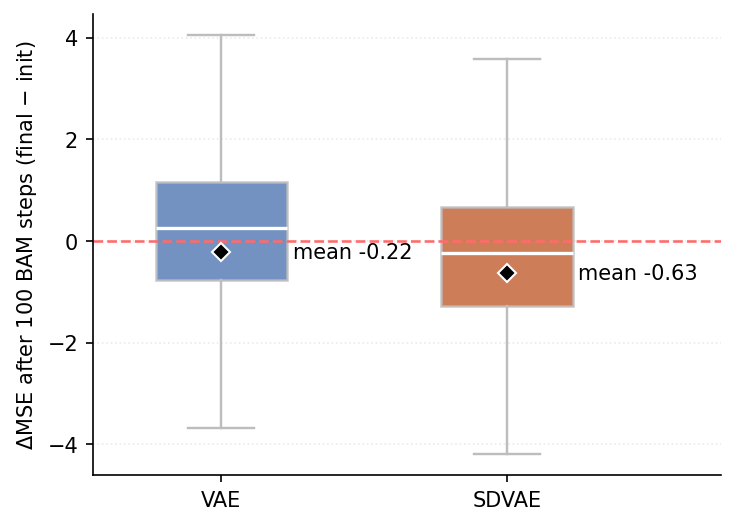

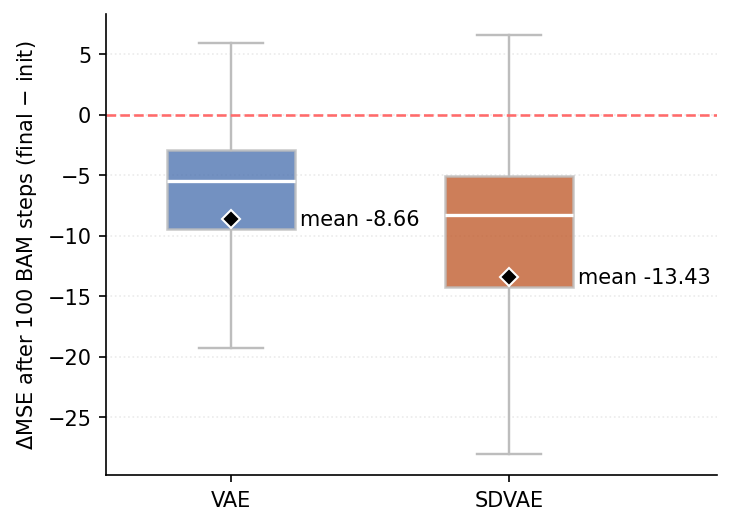

已统一重画并保存：
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_mnist.pdf
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_mnist.png
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_fashion-mnist.pdf
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_fashion-mnist.png
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_cifar10.pdf
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_cifar10.png
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_cifar100.pdf
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_cifar100.png
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_tiny-image-net.pdf
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox_tiny-image-net.png
/home/yzm/ipy/e6_iter_results/refinement_boxplots_all_datasets/refineBox.pdf (MNIST 论文兼容文件名)


In [7]:
saved_paths = []
for dataset in DATASETS:
    pdf_path, png_path = plot_refinement_boxplot(
        dataset=dataset,
        vae_delta=results_in_memory[dataset]["vae"]["delta"],
        sdvae_delta=results_in_memory[dataset]["sdvae"]["delta"],
        output_dir=OUTPUT_DIR,
    )
    saved_paths.extend([pdf_path, png_path])

print("已统一重画并保存：")
for path in saved_paths:
    print(path)
print(OUTPUT_DIR / "refineBox.pdf", "(MNIST 论文兼容文件名)")
